In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from labmate.acquisition_notebook import AcquisitionAnalysisManager


In [12]:
# path_folder_data = r"./data/data_temp_SHG/temp_scan 04 29"
path_folder_data = r"./data/data_temp_SHG/temp_scan 05 04"
folder_data_files = os.listdir(path_folder_data)
print(folder_data_files)

['temp.json', 'temperature_scan']


In [13]:
# fine data scan :
name_exp = 'temperature_scan'
# name = "2026_04_29__15_59_36__temperature_scan.h5"
name = "2026_05_04__17_22_33__temperature_scan.h5"
full_path = os.path.join(path_folder_data, name_exp, name)
aqm = AcquisitionAnalysisManager( os.path.join(path_folder_data, name_exp))
aqm.analysis_cell(filename=full_path)

print(aqm.data)

INFO:2026_05_04__17_22_33__temperature_scan


AnalysisData (rw) (not saved): 
 {
    "acquisition_cell" (r): {
        "1": "variable of type str"
    },
    "experiment_name" (r): "variable of type str",
    "info" (r): {
        "acquisition_duration": "5.521e+02 (type : float64)",
        "logs": "variable of type str",
        "prints": "variable of type str"
    },
    "list_SHG_errors" (r): "shape: (31,) (type: ndarray)",
    "list_SHG_powers" (r): "shape: (31,) (type: ndarray)",
    "list_Terrors" (r): "shape: (31,) (type: ndarray)",
    "list_Tmeas" (r): "shape: (31,) (type: ndarray)",
    "pump_power_mW" (r): "300 (type : int64)",
    "useful" (r): "variable of type bool"
}


In [14]:
list_T = np.array(aqm.data['list_Tmeas'])
list_P = np.array(aqm.data['list_SHG_powers'])
list_Perr = np.array(aqm.data['list_SHG_errors'])
list_Terr = np.array(aqm.data['list_Terrors'])


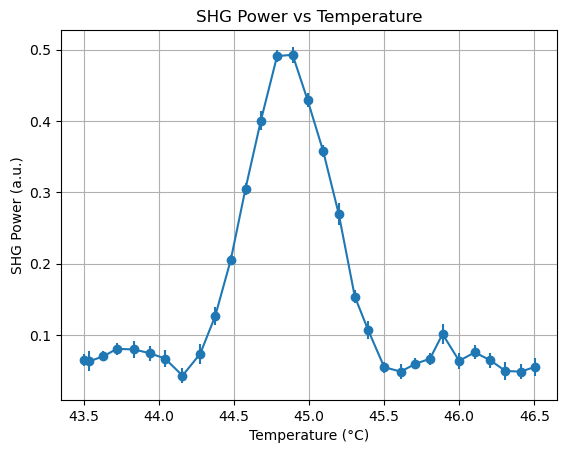

In [15]:
plt.errorbar(list_T, list_P , xerr=list_Terr, yerr=list_Perr, fmt='o-')
plt.xlabel('Temperature (°C)')
plt.ylabel('SHG Power (a.u.)')
plt.title('SHG Power vs Temperature')
plt.grid()
plt.show()
